In [3]:
# This cell imports all the tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This makes charts look nice
plt.style.use('ggplot')
%matplotlib inline

print("Libraries imported successfully!")  

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


In [4]:
# Load the training and test data
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

# Check if loaded correctly
print("Training data shape:", train.shape)
print("Test data shape:", test.shape)
print("\nFirst 5 rows of training data:")
train.head()

Training data shape: (891, 12)
Test data shape: (418, 11)

First 5 rows of training data:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Missing values in training data:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values in test data:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Percentage missing in training data:
Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64


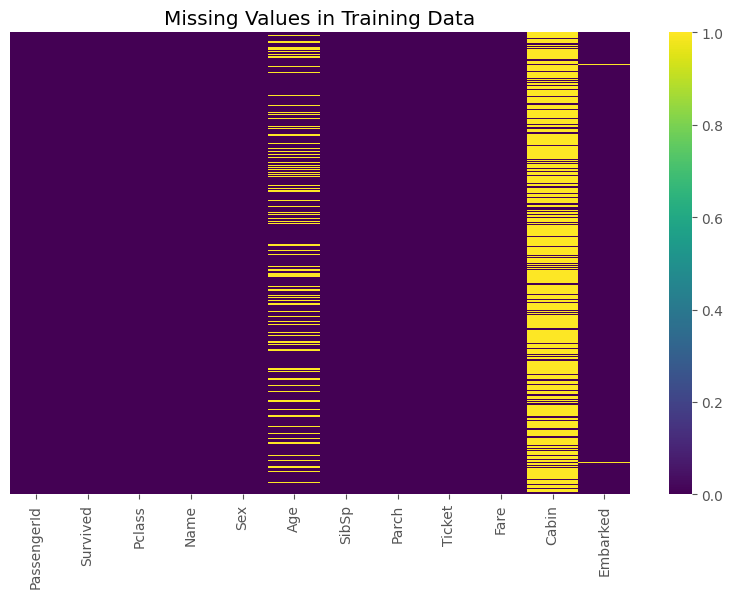

In [5]:
# Check what's missing
print("Missing values in training data:")
print(train.isnull().sum())
print("\n" + "="*50)
print("Missing values in test data:")
print(test.isnull().sum())

# Calculate percentages
print("\n" + "="*50)
print("Percentage missing in training data:")
missing_pct = (train.isnull().sum() / len(train)) * 100
print(missing_pct[missing_pct > 0])

# Visualize missing data
plt.figure(figsize=(10,6))
sns.heatmap(train.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Values in Training Data')
plt.show()

Median Age: 28.0


C:\Users\Camila\AppData\Local\Temp\ipykernel_8856\2167728188.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_clean['Age'].fillna(age_median, inplace=True)
C:\Users\Camila\AppData\Local\Temp\ipykernel_8856\2167728188.py:19: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assig

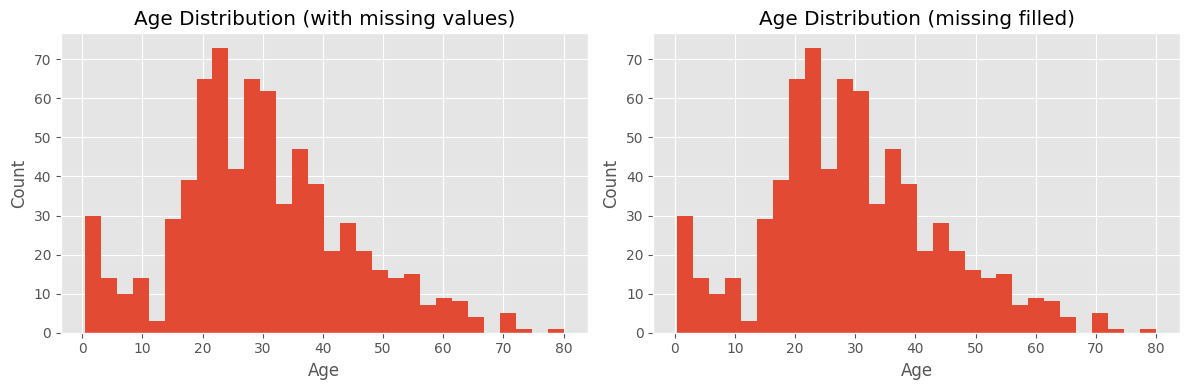

Missing ages filled: 177 values


In [6]:
# Create a copy to work with
train_clean = train.copy()
test_clean = test.copy()

# Check Age distribution
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
train['Age'].hist(bins=30)
plt.title('Age Distribution (with missing values)')
plt.xlabel('Age')
plt.ylabel('Count')

# Calculate median age (excluding missing)
age_median = train['Age'].median()
print(f"Median Age: {age_median}")

# Fill missing ages with median
train_clean['Age'].fillna(age_median, inplace=True)
test_clean['Age'].fillna(age_median, inplace=True)

# Create missing indicator
train_clean['Age_Missing'] = train['Age'].isnull().astype(int)
test_clean['Age_Missing'] = test['Age'].isnull().astype(int)

# Check result
plt.subplot(1,2,2)
train_clean['Age'].hist(bins=30)
plt.title('Age Distribution (missing filled)')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Missing ages filled: {train['Age'].isnull().sum()} values")

In [7]:
# Check Embarked missing
print("Embarked value counts:")
print(train['Embarked'].value_counts())
print(f"\nMissing Embarked: {train['Embarked'].isnull().sum()}")

# Fill with most common value (mode)
embarked_mode = train['Embarked'].mode()[0]
print(f"Mode: {embarked_mode}")

train_clean['Embarked'].fillna(embarked_mode, inplace=True)

# Verify no missing
print(f"\nAfter filling: {train_clean['Embarked'].isnull().sum()} missing")

Embarked value counts:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Missing Embarked: 2
Mode: S

After filling: 2 missing


C:\Users\Camila\AppData\Local\Temp\ipykernel_8856\4130410468.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_clean['Embarked'].fillna(embarked_mode, inplace=True)


In [8]:
# Check Cabin missing
cabin_missing = train['Cabin'].isnull().sum()
cabin_total = len(train)
cabin_pct = (cabin_missing / cabin_total) * 100

print(f"Cabin missing: {cabin_missing} out of {cabin_total} ({cabin_pct:.1f}%)")

# Create missing indicator
train_clean['Cabin_Missing'] = train['Cabin'].isnull().astype(int)
test_clean['Cabin_Missing'] = test['Cabin'].isnull().astype(int)

# Drop original Cabin column
train_clean.drop('Cabin', axis=1, inplace=True)
test_clean.drop('Cabin', axis=1, inplace=True)

print("Cabin column dropped, missing indicator created")

Cabin missing: 687 out of 891 (77.1%)
Cabin column dropped, missing indicator created


In [9]:
# Check Sex values
print("Unique Sex values:", train['Sex'].unique())

# Standardize (they're already fine, but good practice)
train_clean['Sex'] = train_clean['Sex'].map({'male': 'male', 'female': 'female'})
test_clean['Sex'] = test_clean['Sex'].map({'male': 'male', 'female': 'female'})

# Check for duplicates
duplicates = train_clean.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Unique Sex values: <StringArray>
['male', 'female']
Length: 2, dtype: str
Duplicate rows: 0


Age outliers: 11 rows


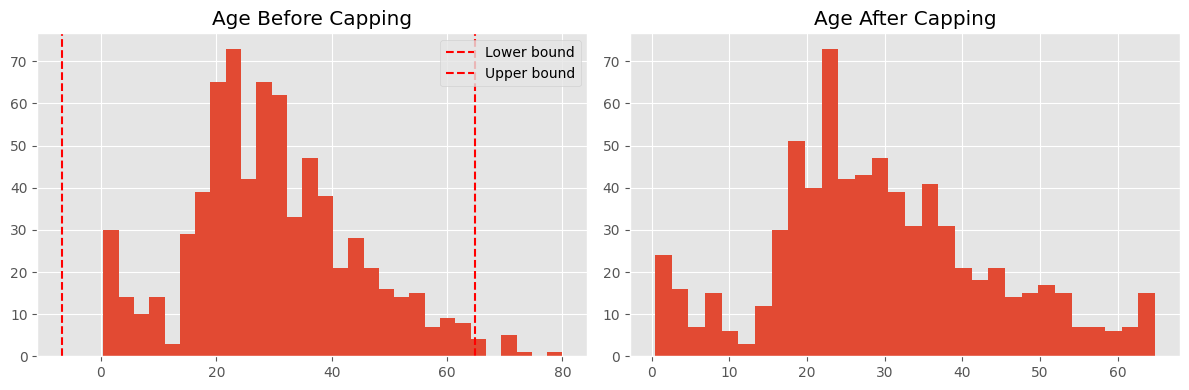

In [10]:
# Detect outliers in Age
Q1_age = train_clean['Age'].quantile(0.25)
Q3_age = train_clean['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

outliers_age = train_clean[(train_clean['Age'] < lower_age) | (train_clean['Age'] > upper_age)]
print(f"Age outliers: {len(outliers_age)} rows")

# Visualize before
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
train_clean['Age'].hist(bins=30)
plt.title('Age Before Capping')
plt.axvline(lower_age, color='r', linestyle='--', label='Lower bound')
plt.axvline(upper_age, color='r', linestyle='--', label='Upper bound')
plt.legend()

# Cap outliers
train_clean['Age'] = train_clean['Age'].clip(lower_age, upper_age)
test_clean['Age'] = test_clean['Age'].clip(lower_age, upper_age)

# Visualize after
plt.subplot(1,2,2)
train_clean['Age'].hist(bins=30)
plt.title('Age After Capping')
plt.tight_layout()
plt.show()

Fare outliers: 116 rows


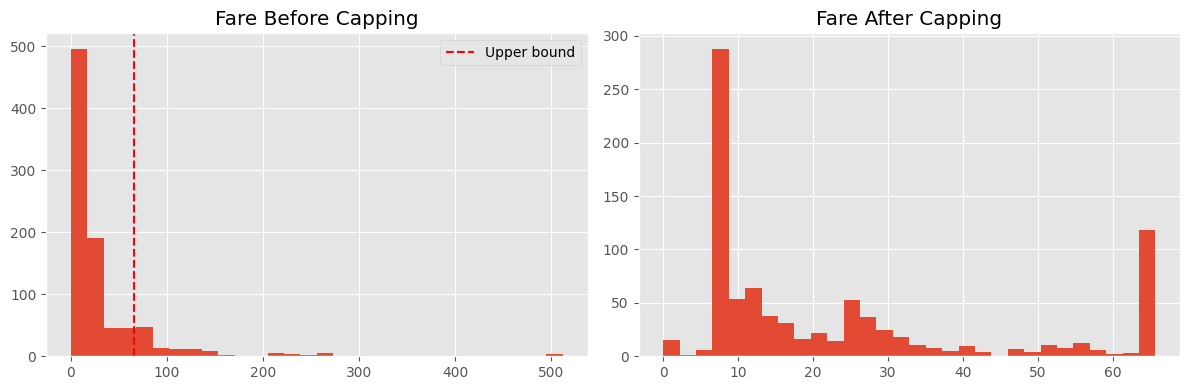

In [11]:
# Detect outliers in Fare
Q1_fare = train_clean['Fare'].quantile(0.25)
Q3_fare = train_clean['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

outliers_fare = train_clean[(train_clean['Fare'] < lower_fare) | (train_clean['Fare'] > upper_fare)]
print(f"Fare outliers: {len(outliers_fare)} rows")

# Visualize before
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
train_clean['Fare'].hist(bins=30)
plt.title('Fare Before Capping')
plt.axvline(upper_fare, color='r', linestyle='--', label='Upper bound')
plt.legend()

# Cap outliers (only upper bound, lower bound is 0)
train_clean['Fare'] = train_clean['Fare'].clip(0, upper_fare)
test_clean['Fare'] = test_clean['Fare'].clip(0, upper_fare)

# Visualize after
plt.subplot(1,2,2)
train_clean['Fare'].hist(bins=30)
plt.title('Fare After Capping')
plt.tight_layout()
plt.show()

In [12]:
# Save cleaned datasets
train_clean.to_csv('../data/train_cleaned.csv', index=False)
test_clean.to_csv('../data/test_cleaned.csv', index=False)

print("Cleaned data saved successfully!")
print(f"Train shape: {train_clean.shape}")
print(f"Test shape: {test_clean.shape}")

Cleaned data saved successfully!
Train shape: (891, 13)
Test shape: (418, 12)
